# Gas-driven permeation: Chebyshev vs. FESTIM vs. analytical

The TDS notebook (`tds_inverse.ipynb`) measures spectral-vs-algebraic
convergence against an over-resolved Chebyshev *reference*, because TDS
with two traps and a Gaussian source has no closed form. Permeation under
a Sieverts upstream and a zero-concentration downstream does have a
closed-form Fourier-series solution for the downstream flux, so we can
measure error against truth directly. The transient profile also has a
moving boundary layer at the upstream surface and a smooth quasi-linear
gradient downstream — exactly the regime where Chebyshev-Gauss-Lobatto
clustering at both ends pays off and a uniform FEM mesh does not.

Both solvers run with the **same backward-Euler controller**: matched
`Stepsize` settings and a `max_stepsize` cap of 0.05 s, exactly the
FESTIM-workshop time step. The shared temporal scheme isolates spatial
discretization error in the relative-L2 metric, except below the BE
temporal floor — which we measure separately in the diagnostic cell at
the bottom.

## 1. Imports and constants

In [1]:
import os
import time
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import festim as F
import chebyshev_festim as CF

In [2]:
# physical constants
K_B_EV = 8.617333262145e-5        # eV / K

# FESTIM workshop permeation problem
L          = 3e-4                 # m, foil thickness
T_CONST    = 500.0                # K, isothermal
P_UP       = 100.0                # Pa, upstream H2 partial pressure
D_0, E_D   = 1.9e-7, 0.2          # m^2/s, eV   (Arrhenius diffusivity)
S_0, E_S   = 4.02e21, 1.04        # H/m^3/Pa^0.5, eV  (Sieverts solubility)
FINAL_TIME = 100.0                # s

# shared time-stepping schedule
MAX_DT = 0.05                     # s, BE step cap (matches workshop)

D = D_0 * np.exp(-E_D / (K_B_EV * T_CONST))
S = S_0 * np.exp(-E_S / (K_B_EV * T_CONST))
PERMEABILITY = D * S
STEADY_FLUX = P_UP**0.5 * PERMEABILITY / L

FIG_DIR = os.path.join("..", "figs")
os.makedirs(FIG_DIR, exist_ok=True)

print(f"D(T)            = {D:.3e} m^2/s")
print(f"S(T)            = {S:.3e} H/m^3/Pa^0.5")
print(f"permeability    = {PERMEABILITY:.3e}")
print(f"steady-state J  = {STEADY_FLUX:.3e} H/m^2/s")
print(f"diffusion time  = L^2 / D = {L*L/D:.2f} s   (final_time = {FINAL_TIME} s)")
print(f"BE step cap     = {MAX_DT} s   ({int(FINAL_TIME / MAX_DT)} steps if dt saturates)")

D(T)            = 1.832e-09 m^2/s
S(T)            = 1.323e+11 H/m^3/Pa^0.5
permeability    = 2.423e+02
steady-state J  = 8.076e+06 H/m^2/s
diffusion time  = L^2 / D = 49.14 s   (final_time = 100.0 s)
BE step cap     = 0.05 s   (2000 steps if dt saturates)


## 2. Analytical reference

Crank's classical solution for the downstream flux under a Sieverts
upstream BC and a zero-concentration downstream BC, for a slab initially
free of solute:

$$
J(t) = \frac{P_{\mathrm{up}}^{1/2}\,K}{L}
\Bigl(1 + 2\sum_{n=1}^{\infty} (-1)^n\,
\exp\!\bigl(-n^2 \pi^2 D\,t / L^2\bigr)\Bigr),
$$

with permeability $K = D \cdot S$. The series is truncated at $n=10\,000$
— far past convergence at every $t$ we evaluate.

In [3]:
def downstream_flux(t, P_up, permeability, L, D, n_terms=10000):
    '''Analytical downstream H flux (Crank, Sieverts upstream / zero downstream).

    Parameters mirror the FESTIM workshop example. `t` may be a scalar or array.
    '''
    n = np.arange(1, n_terms)[:, None]
    s = np.sum((-1)**n * np.exp(-(np.pi * n)**2 * D / L**2 * np.atleast_1d(t)),
               axis=0)
    return P_up**0.5 * permeability / L * (2 * s + 1)

## 3. Metric helpers and observation grid

In [4]:
def spectrum_on_grid(t, flux, t_grid):
    '''Resample (t, flux) onto a common grid via linear interpolation.
    Edges are clamped to the boundary samples (the steady-state plateau).'''
    return np.interp(t_grid, t, flux,
                     left=float(flux[0]), right=float(flux[-1]))


def relative_l2(test, ref):
    return float(np.linalg.norm(test - ref)
                 / max(np.linalg.norm(ref), 1e-30))


# Skip the dead-time plateau where the relative-L2 metric is dominated by
# near-zero values: breakthrough begins around L^2 / (pi^2 D) ~ 5 s here.
T_OBS_START = 1.0  # s
t_obs = np.linspace(T_OBS_START, FINAL_TIME, 400)
analytical_obs = downstream_flux(t_obs, P_UP, PERMEABILITY, L, D)

print(f"observation grid: t in [{T_OBS_START}, {FINAL_TIME}] s, {len(t_obs)} points")
print(f"analytical J(t_obs[0])  = {analytical_obs[0]:.3e}")
print(f"analytical J(t_obs[-1]) = {analytical_obs[-1]:.3e}")
print(f"steady-state J          = {STEADY_FLUX:.3e}  (expected match at large t)")

observation grid: t in [1.0, 100.0] s, 400 points
analytical J(t_obs[0])  = 2.955e+02
analytical J(t_obs[-1]) = 8.076e+06
steady-state J          = 8.076e+06  (expected match at large t)


## 4. FESTIM forward (uniform mesh)

Mirrors the workshop tutorial line-for-line. The convergence study sweeps
`n_cells` (number of P1 cells on a uniform mesh). The time-integrator
knobs are exposed but pinned at `MAX_DT = 0.05 s` to match the Chebyshev
side, so any difference in rel-L2 is purely spatial above the BE floor.

In [5]:
def run_festim_perm(n_cells, atol=1e-2, rtol=1e-10, max_stepsize=MAX_DT,
                    element_degree=1):
    my = F.HydrogenTransportProblem()
    my.mesh = F.Mesh1D(np.linspace(0, L, n_cells + 1))

    material = F.Material(D_0=D_0, E_D=E_D)
    vol = F.VolumeSubdomain1D(id=1, borders=[0, L], material=material)
    left = F.SurfaceSubdomain1D(id=2, x=0)
    right = F.SurfaceSubdomain1D(id=3, x=L)
    my.subdomains = [vol, left, right]

    H = F.Species("H")
    my.species = [H]
    my.boundary_conditions = [
        F.SievertsBC(subdomain=left, S_0=S_0, E_S=E_S,
                     pressure=P_UP, species=H),
        F.FixedConcentrationBC(subdomain=right, value=0, species=H),
    ]
    my.temperature = T_CONST
    my.settings = F.Settings(atol=atol, rtol=rtol, final_time=FINAL_TIME,
                             element_degree=element_degree)
    my.settings.stepsize = F.Stepsize(
        initial_value=max_stepsize, growth_factor=1.1,
        cutback_factor=0.5, target_nb_iterations=4,
        max_stepsize=max_stepsize,
    )
    flux = F.SurfaceFlux(field=H, surface=right)
    my.exports = [flux]

    with open(os.devnull, "w") as devnull, contextlib.redirect_stderr(devnull):
        my.initialise()

        # Wrap the Newton solver to accumulate "real numerical work" time.
        # Excludes per-step SurfaceFlux post-processing, which a profile shows
        # is dominated by FFCx JIT cache directory scans (the form is rebuilt
        # each timestep). Reports Newton-solve-only wall time alongside the
        # total `run()` cost.
        original_solve = my.solver.solve
        t_newton = 0.0
        def timed_solve(*args, **kwargs):
            nonlocal t_newton
            s0 = time.time()
            out = original_solve(*args, **kwargs)
            t_newton += time.time() - s0
            return out
        my.solver.solve = timed_solve

        t0 = time.time()
        my.run()
        t_total = time.time() - t0
    return np.asarray(flux.t), np.abs(np.asarray(flux.data)), t_newton, t_total

## 5. Chebyshev forward

`left_stretch=0.0` is the right default for permeation: plain CGL nodes
cluster at both endpoints, which resolves the upstream Sieverts boundary
layer and the downstream gradient (where the flux is measured) at the
same time. The TDS notebook used `left_stretch=6.0` because the Gaussian
source sat near the upstream surface — that is not a feature of this
problem.

In [6]:
def run_chebyshev_perm(N, atol=1e-2, rtol=1e-10, max_stepsize=MAX_DT,
                       left_stretch=0.0):
    my = CF.HydrogenTransportProblem()
    my.mesh = CF.ChebyshevMesh1D(N=N, x_max=L, left_stretch=left_stretch)

    material = CF.Material(D_0=D_0, E_D=E_D)
    vol = CF.VolumeSubdomain1D(id=1, borders=(0, L), material=material)
    left = CF.SurfaceSubdomain1D(id=2, x=0)
    right = CF.SurfaceSubdomain1D(id=3, x=L)
    my.subdomains = [vol, left, right]

    H = CF.Species("H")
    my.species = [H]
    my.boundary_conditions = [
        CF.SievertsBC(subdomain=left, S_0=S_0, E_S=E_S,
                      pressure=P_UP, species=H),
        CF.FixedConcentrationBC(subdomain=right, value=0.0, species=H),
    ]
    my.temperature = T_CONST
    my.settings = CF.Settings(atol=atol, rtol=rtol, final_time=FINAL_TIME)
    my.settings.stepsize = CF.Stepsize(
        initial_value=max_stepsize, growth_factor=1.1,
        cutback_factor=0.5, target_nb_iterations=4,
        max_stepsize=max_stepsize,
    )
    flux = CF.SurfaceFlux(field=H, surface=right)
    my.exports = [flux]
    my.initialise()
    t0 = time.time()
    my.run(verbose=False)
    t_solve = time.time() - t0
    return np.asarray(flux.t), np.abs(np.asarray(flux.data)), t_solve

## 6. Forward demo

Run each method once at a moderate resolution and overlay all three
traces. Both numerical curves should sit on top of the analytical line
with no visible separation; the steady-state value $J_\infty = P_{\rm up}^{1/2}\,DS/L$
is reached well before $t = 100$ s.

FESTIM  steady-state @t=100.0s : 8.0761e+06
Cheby   steady-state @t=100.0s : 8.0762e+06
analyt  steady-state           : 8.0762e+06


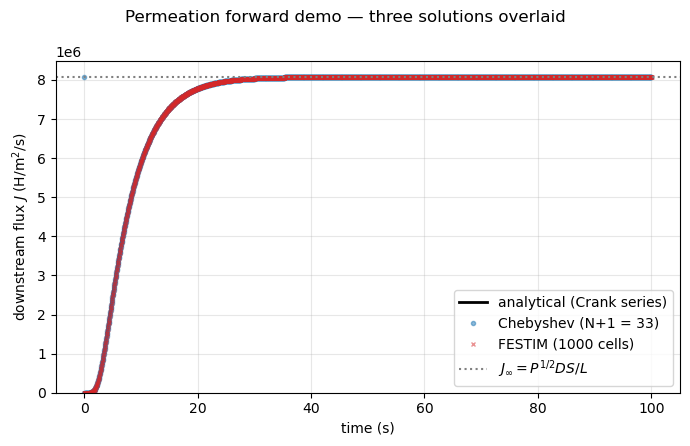

In [7]:
t_c, fl_c, _ = run_chebyshev_perm(N=32)
t_f, fl_f, _, _ = run_festim_perm(n_cells=1000)

t_dense = np.linspace(0.05, FINAL_TIME, 1000)
ana = downstream_flux(t_dense, P_UP, PERMEABILITY, L, D)

print(f"FESTIM  steady-state @t={t_f[-1]:.1f}s : {fl_f[-1]:.4e}")
print(f"Cheby   steady-state @t={t_c[-1]:.1f}s : {fl_c[-1]:.4e}")
print(f"analyt  steady-state           : {STEADY_FLUX:.4e}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t_dense, ana, "k-", lw=2, label="analytical (Crank series)")
ax.plot(t_c, fl_c, "o", color="C0", ms=3, alpha=0.5,
        label="Chebyshev (N+1 = 33)")
ax.plot(t_f, fl_f, "x", color="C3", ms=3, alpha=0.5,
        label="FESTIM (1000 cells)")
ax.axhline(STEADY_FLUX, ls=":", color="grey", label=r"$J_\infty = P^{1/2} DS/L$")
ax.set_xlabel("time (s)")
ax.set_ylabel(r"downstream flux $J$ (H/m$^2$/s)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3); ax.legend()
fig.suptitle("Permeation forward demo — three solutions overlaid")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "permeation_forward.pdf"),
            bbox_inches="tight")
plt.show()

## 7. Chebyshev p-convergence

Sweep polynomial degree $N$ at fixed time-step controller and measure
rel-L2 against the analytical solution on the common observation grid.
Expected behaviour: very fast (geometric) convergence in $N$ down to the
BE temporal floor, then a flat plateau. The smallest values of $N$ are
where the spatial error is large enough to dominate the temporal one.

In [8]:
Ns_cheb = (4, 6, 8, 12, 16, 24, 32, 48)

times_cheb, errs_cheb, fluxes_cheb_obs = [], [], []
print("Chebyshev p-convergence (rel-L2 vs analytical)\n")
for N in Ns_cheb:
    t, fl, w = run_chebyshev_perm(N=N)
    fl_obs = spectrum_on_grid(t, fl, t_obs)
    e = relative_l2(fl_obs, analytical_obs)
    times_cheb.append(w); errs_cheb.append(e); fluxes_cheb_obs.append(fl_obs)
    print(f"  N+1 = {N+1:3d}   wall = {w:5.2f} s   rel-L2 = {e:.3e}")

Chebyshev p-convergence (rel-L2 vs analytical)

  N+1 =   5   wall =  0.19 s   rel-L2 = 1.266e-02


  N+1 =   7   wall =  0.18 s   rel-L2 = 1.825e-03
  N+1 =   9   wall =  0.19 s   rel-L2 = 9.730e-04


  N+1 =  13   wall =  0.19 s   rel-L2 = 9.435e-04
  N+1 =  17   wall =  0.20 s   rel-L2 = 9.436e-04


  N+1 =  25   wall =  0.21 s   rel-L2 = 9.436e-04


  N+1 =  33   wall =  0.22 s   rel-L2 = 9.436e-04


  N+1 =  49   wall =  0.27 s   rel-L2 = 9.436e-04


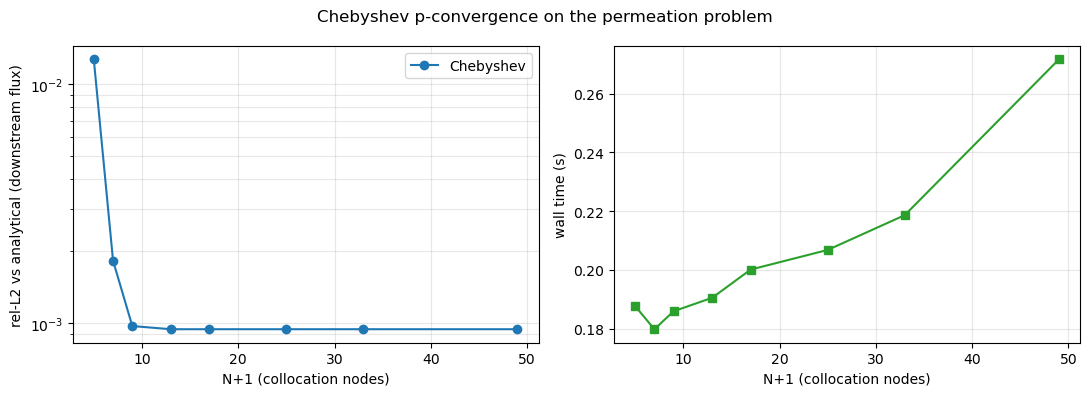

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(np.array(Ns_cheb) + 1, errs_cheb, "o-", color="C0",
               label="Chebyshev")
ax[0].set_xlabel("N+1 (collocation nodes)")
ax[0].set_ylabel("rel-L2 vs analytical (downstream flux)")
ax[0].grid(alpha=0.3, which="both"); ax[0].legend()

ax[1].plot(np.array(Ns_cheb) + 1, times_cheb, "s-", color="C2")
ax[1].set_xlabel("N+1 (collocation nodes)")
ax[1].set_ylabel("wall time (s)")
ax[1].grid(alpha=0.3)

fig.suptitle("Chebyshev p-convergence on the permeation problem")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "permeation_cheb_sweep.pdf"),
            bbox_inches="tight")
plt.show()

## 8. FESTIM h-convergence

Sweep uniform-mesh cell count at the same time-step controller and
measure rel-L2 against the analytical reference. Expected behaviour:
$O(h^2)$ algebraic convergence — slope $-2$ on a log-log axis — until
the temporal-error floor takes over.

Wall time here is reported as **Newton-solve time only**: we wrap
`my.solver.solve` so each of its 2000 calls is summed, and ignore the
rest of `my.run()`. A profile of the full `run()` shows that ~63% of
its cost comes from `SurfaceFlux.compute()` rebuilding its UFL form
each timestep and triggering FFCx JIT cache directory scans (`os.listdir`
fires 2000+ times); only ~35% is the actual Newton solve. Reporting
total `run()` time would conflate the spatial-discretization cost we
care about with that fixed per-step framework overhead, which is
independent of mesh resolution. The total is still printed in the
sweep table for context.

In [10]:
n_cells_fes = (5, 10, 25, 50, 100, 250, 500, 1000)

times_fes, totals_fes, errs_fes, dofs_fes, fluxes_fes_obs = [], [], [], [], []
print("FESTIM h-convergence (rel-L2 vs analytical)\n")
print(f"  {'cells':>5}  {'verts':>5}  {'Newton':>7}  {'total':>7}  rel-L2")
for nc in n_cells_fes:
    t, fl, t_newton, t_total = run_festim_perm(n_cells=nc)
    fl_obs = spectrum_on_grid(t, fl, t_obs)
    e = relative_l2(fl_obs, analytical_obs)
    times_fes.append(t_newton); totals_fes.append(t_total)
    errs_fes.append(e); dofs_fes.append(nc + 1); fluxes_fes_obs.append(fl_obs)
    flag = "  *truncated*" if t[-1] < FINAL_TIME - 0.5 else ""
    print(f"  {nc:>5d}  {nc+1:>5d}  {t_newton:6.2f}s  {t_total:6.2f}s   "
          f"{e:.3e}{flag}")

FESTIM h-convergence (rel-L2 vs analytical)

  cells  verts   Newton    total  rel-L2


      5      6   13.57s   22.13s   8.741e-03


     10     11   16.63s   26.28s   1.549e-03


     25     26   16.46s   26.92s   6.500e-04


     50     51   16.28s   26.89s   8.678e-04


    100    101   15.31s   26.02s   9.268e-04


    250    251   17.75s   27.98s   9.435e-04


    500    501   17.19s   27.09s   9.459e-04


   1000   1001   19.63s   28.69s   9.465e-04


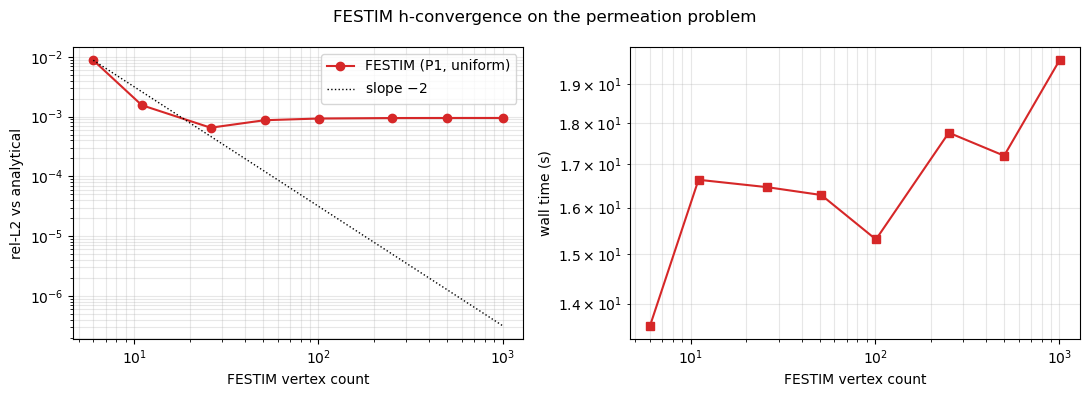

In [11]:
dofs_fes_arr = np.array(dofs_fes)
errs_fes_arr = np.array(errs_fes)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(dofs_fes_arr, errs_fes_arr, "o-", color="C3",
             label="FESTIM (P1, uniform)")
# slope-2 reference triangle anchored at the coarsest point
d_lo, d_hi = dofs_fes_arr.min(), dofs_fes_arr.max()
e_lo = errs_fes_arr[0]
ax[0].loglog([d_lo, d_hi], [e_lo, e_lo * (d_hi / d_lo) ** -2],
             "k:", lw=1, label=r"slope $-2$")
ax[0].set_xlabel("FESTIM vertex count")
ax[0].set_ylabel("rel-L2 vs analytical")
ax[0].grid(alpha=0.3, which="both"); ax[0].legend()

ax[1].loglog(dofs_fes_arr, times_fes, "s-", color="C3")
ax[1].set_xlabel("FESTIM vertex count")
ax[1].set_ylabel("wall time (s)")
ax[1].grid(alpha=0.3, which="both")

fig.suptitle("FESTIM h-convergence on the permeation problem")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "permeation_festim_sweep.pdf"),
            bbox_inches="tight")
plt.show()

## 9. Spectral vs. algebraic — the headline

Both convergence curves on the same axes (DOFs on $x$, rel-L2 on $y$),
and the wall-time efficiency frontier (rel-L2 on $x$, wall time on $y$).
The matched-accuracy summary at the bottom reads off the smallest DOF
count and wall time on each curve below the target tolerance.

We pick `target_err = 2e-3`, comfortably above the BE-at-$dt=0.05$
temporal floor (about $9\times 10^{-4}$ for both methods). Below that
floor neither method can improve without a higher-order time integrator,
so a target there would say more about the time scheme than about the
spatial discretization.

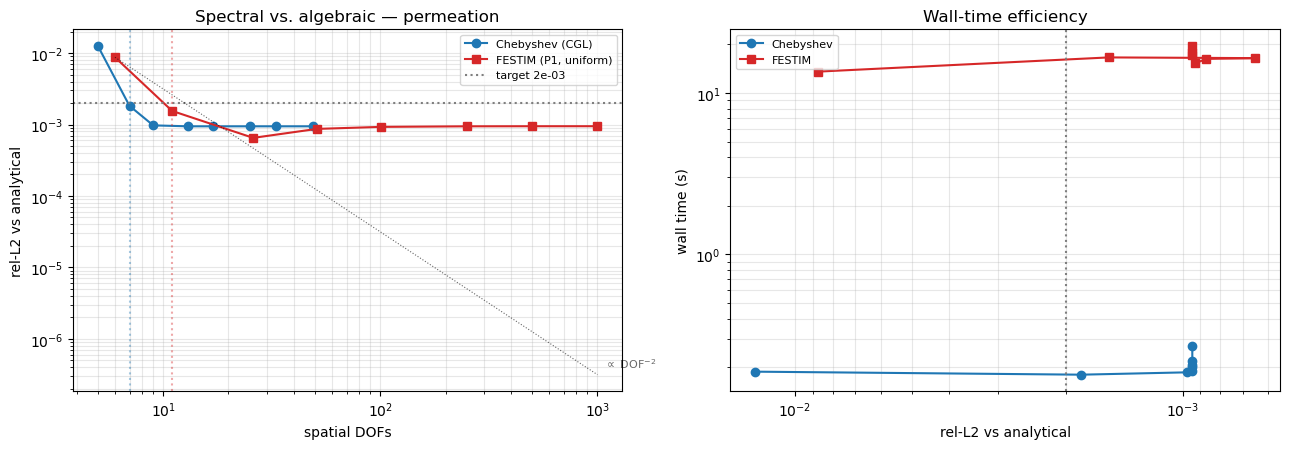

matched accuracy: rel-L2 < 2e-03

  Chebyshev: DOFs =     7  wall =   0.18 s   actual err = 1.82e-03
  FESTIM   : DOFs =    11  wall =  16.63 s   actual err = 1.55e-03

  matched-accuracy speedup (FESTIM / Chebyshev): 92.5x
  matched-accuracy DOF reduction (FESTIM / Chebyshev): 1.6x


In [12]:
dofs_cheb = np.array(Ns_cheb) + 1
errs_cheb_arr = np.array(errs_cheb)


def _matched_accuracy(dofs, errs, walls, target):
    for d, e, w in zip(dofs, errs, walls):
        if e < target:
            return int(d), float(w), float(e)
    return None, None, None


target_err = 2e-3
d_c, w_c, e_c = _matched_accuracy(dofs_cheb, errs_cheb, times_cheb, target_err)
d_f, w_f, e_f = _matched_accuracy(dofs_fes_arr, errs_fes, times_fes, target_err)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# panel 1: error vs DOFs (log-log)
ax[0].loglog(dofs_cheb, errs_cheb_arr, "o-", color="C0", lw=1.5,
             label="Chebyshev (CGL)")
ax[0].loglog(dofs_fes_arr, errs_fes_arr, "s-", color="C3", lw=1.5,
             label="FESTIM (P1, uniform)")
ax[0].axhline(target_err, color="C7", ls=":",
              label=f"target {target_err:.0e}")

# slope-2 guide for FEM, anchored to the most under-resolved point
d_lo, d_hi = dofs_fes_arr.min(), dofs_fes_arr.max()
e_lo = errs_fes_arr[0]
ax[0].loglog([d_lo, d_hi], [e_lo, e_lo * (d_hi / d_lo) ** -2],
             "k:", lw=0.8, alpha=0.6)
ax[0].annotate(r"$\propto$ DOF$^{-2}$",
               xy=(d_hi, e_lo * (d_hi / d_lo) ** -2),
               xytext=(5, 5), textcoords="offset points",
               fontsize=8, alpha=0.6)

if d_c is not None:
    ax[0].axvline(d_c, color="C0", ls=":", alpha=0.4)
if d_f is not None:
    ax[0].axvline(d_f, color="C3", ls=":", alpha=0.4)

ax[0].set_xlabel("spatial DOFs")
ax[0].set_ylabel("rel-L2 vs analytical")
ax[0].set_title("Spectral vs. algebraic — permeation")
ax[0].grid(alpha=0.3, which="both"); ax[0].legend(fontsize=8)

# panel 2: wall time vs error (efficiency frontier)
ax[1].loglog(errs_cheb_arr, times_cheb, "o-", color="C0", lw=1.5,
             label="Chebyshev")
ax[1].loglog(errs_fes_arr, times_fes, "s-", color="C3", lw=1.5,
             label="FESTIM")
ax[1].axvline(target_err, color="C7", ls=":")
ax[1].set_xlabel("rel-L2 vs analytical")
ax[1].set_ylabel("wall time (s)")
ax[1].set_title("Wall-time efficiency")
ax[1].grid(alpha=0.3, which="both"); ax[1].legend(fontsize=8)
ax[1].invert_xaxis()  # better accuracy on the right

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "permeation_spectral_vs_algebraic.pdf"),
            bbox_inches="tight")
plt.show()

# matched-accuracy summary
print(f"matched accuracy: rel-L2 < {target_err:.0e}\n")
if d_c is not None:
    print(f"  Chebyshev: DOFs = {d_c:>5d}  wall = {w_c:6.2f} s   "
          f"actual err = {e_c:.2e}")
else:
    print("  Chebyshev: did not reach target in tested range")
if d_f is not None:
    print(f"  FESTIM   : DOFs = {d_f:>5d}  wall = {w_f:6.2f} s   "
          f"actual err = {e_f:.2e}")
else:
    print("  FESTIM   : did not reach target in tested range")
if d_c is not None and d_f is not None:
    print(f"\n  matched-accuracy speedup (FESTIM / Chebyshev): {w_f/w_c:.1f}x")
    print(f"  matched-accuracy DOF reduction (FESTIM / Chebyshev): "
          f"{d_f/d_c:.1f}x")

## 10. Time-integrator floor diagnostic

Re-run the highest-resolution Chebyshev case at half the max stepsize.
The rel-L2 between the two solves is the temporal-error floor — any
spatial-error sweep point at or below this floor is masked by
backward-Euler error rather than spatial discretization.

In [13]:
N_FLOOR = max(Ns_cheb)
t_a, fl_a, _ = run_chebyshev_perm(N=N_FLOOR, max_stepsize=MAX_DT)
t_b, fl_b, _ = run_chebyshev_perm(N=N_FLOOR, max_stepsize=MAX_DT / 2)

fl_a_grid = spectrum_on_grid(t_a, fl_a, t_obs)
fl_b_grid = spectrum_on_grid(t_b, fl_b, t_obs)

be_floor = relative_l2(fl_a_grid, fl_b_grid)
be_truth = relative_l2(fl_a_grid, analytical_obs)
be_truth_half = relative_l2(fl_b_grid, analytical_obs)

print(f"At Chebyshev N+1 = {N_FLOOR+1}:")
print(f"  rel-L2(dt={MAX_DT}    vs analytical) = {be_truth:.3e}")
print(f"  rel-L2(dt={MAX_DT/2}  vs analytical) = {be_truth_half:.3e}")
print(f"  rel-L2(dt={MAX_DT}    vs dt={MAX_DT/2}) = {be_floor:.3e}   <- BE temporal floor")
print()
print("Any spatial-error sweep point at or below the BE floor is masked\n"
      "by time-integration error rather than spatial discretization.")

At Chebyshev N+1 = 49:
  rel-L2(dt=0.05    vs analytical) = 9.436e-04
  rel-L2(dt=0.025  vs analytical) = 4.744e-04
  rel-L2(dt=0.05    vs dt=0.025) = 4.693e-04   <- BE temporal floor

Any spatial-error sweep point at or below the BE floor is masked
by time-integration error rather than spatial discretization.


## 11. Decomposing the error: spatial vs temporal

The §9 panels measure rel-L2 against the analytical (Crank) solution,
which mixes two distinct error sources: **spatial discretization**
(Chebyshev finite-N or FESTIM finite-h) and **time integration** (BE
at $dt = 0.05$ s — the floor measured in §10). Two complementary ways
to factor them apart:

**Panel A — cheb-reference decomposition** (borrowed from
`permeation_timelag_compare.ipynb`): swap the analytical reference for
a high-resolution Chebyshev BE solve at the same dt. Both test and
reference share the same time integrator, so the BE temporal error
cancels in the difference, leaving **pure spatial-discretization
error under BE dynamics**. Panel A also adds two FESTIM P-refinement
sweeps (P2, P3) using FESTIM's native `Settings(element_degree=k)`,
showing the expected $O(\mathrm{DOF}^{-(k+1)})$ slopes until the
cross-solver noise floor (~10⁻⁵) takes over. Other higher-order knobs
visible in `basix.LagrangeVariant` (gll_warped, chebyshev_warped,
bernstein) are not exposed by FESTIM's public API and would only
change conditioning at high p, not asymptotic order.

**Panel B — Richardson extrapolation in time**: for each spatial
point, run twice at $dt$ and $dt/2$, then combine
$u_{\rm Rich} = 2 u(dt/2) - u(dt)$. BE error obeys $u^{\rm BE} =
u^{\rm exact} + C\,\Delta t + O(\Delta t^2)$, so the linear term cancels
and the residual temporal floor drops to $O(\Delta t^2)$. P2/P3 are
omitted from Panel B because the FESTIM-internal Richardson floor
(~10⁻⁵) sits at the same level as the cross-solver floor in Panel A,
so the higher-order curves would tell the same story at twice the
compute cost.

Panel A: Chebyshev BE spatial reference (N+1 = 97) ...


FESTIM P2 sweep (4 points) ...


FESTIM P3 sweep (4 points) ...


Panel B: Chebyshev half-dt sweep ...


Panel B: FESTIM P1 half-dt sweep (slow) ...


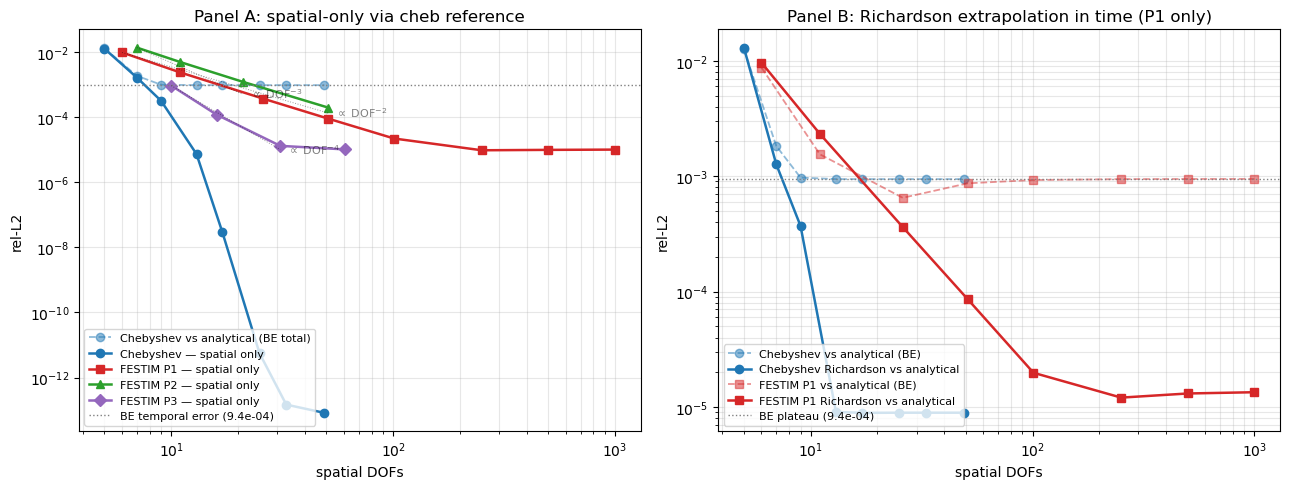


Chebyshev: total / spatial-only / Richardson
  N+1 =   5   total = 1.27e-02   spatial = 1.24e-02   Rich = 1.30e-02
  N+1 =   7   total = 1.82e-03   spatial = 1.61e-03   Rich = 1.27e-03
  N+1 =   9   total = 9.73e-04   spatial = 3.12e-04   Rich = 3.71e-04
  N+1 =  13   total = 9.44e-04   spatial = 7.24e-06   Rich = 9.07e-06
  N+1 =  17   total = 9.44e-04   spatial = 2.91e-08   Rich = 8.89e-06
  N+1 =  25   total = 9.44e-04   spatial = 5.58e-12   Rich = 8.92e-06
  N+1 =  33   total = 9.44e-04   spatial = 1.48e-13   Rich = 8.92e-06
  N+1 =  49   total = 9.44e-04   spatial = 8.29e-14   Rich = 8.92e-06

FESTIM P1: total / spatial-only / Richardson
  verts =    6   total = 8.74e-03   spatial = 9.50e-03   Rich = 9.64e-03
  verts =   11   total = 1.55e-03   spatial = 2.31e-03   Rich = 2.33e-03
  verts =   26   total = 6.50e-04   spatial = 3.62e-04   Rich = 3.63e-04
  verts =   51   total = 8.68e-04   spatial = 8.85e-05   Rich = 8.60e-05
  verts =  101   total = 9.27e-04   spatial = 2.17e-05  

In [14]:
# ----- Panel A reference: Chebyshev BE at very large N --------------
# By §10, spatial error is below the BE floor for any N+1 >= 13, so
# N+1 = 97 has the same temporal error as every test solve. That
# shared temporal error cancels out of (test - ref).
N_REF_CHEB = 96
print(f"Panel A: Chebyshev BE spatial reference (N+1 = {N_REF_CHEB+1}) ...")
t_ref, fl_ref, _ = run_chebyshev_perm(N=N_REF_CHEB)
flux_ref_cheb = spectrum_on_grid(t_ref, fl_ref, t_obs)

errs_cheb_spatial = np.array([
    relative_l2(fl_obs, flux_ref_cheb) for fl_obs in fluxes_cheb_obs
])
errs_fes_spatial = np.array([
    relative_l2(fl_obs, flux_ref_cheb) for fl_obs in fluxes_fes_obs
])

# ----- Panel A: higher-order FEM in FESTIM (P2 and P3) --------------
# FESTIM v2 exposes spatial element degree via Settings(element_degree=).
# Default is 1 (P1 linear Lagrange, O(h^2)); P2 quadratic gives O(h^3),
# P3 cubic gives O(h^4). Other native FESTIM/dolfinx options not exposed
# through FESTIM's public API: basix.LagrangeVariant (gll_warped,
# chebyshev_warped, bernstein) — same asymptotic convergence as the
# default equispaced, only changes conditioning at high p; would need
# a small monkey-patch on define_function_spaces to swap.
def fes_p_sweep(p, n_cells_list):
    print(f"FESTIM P{p} sweep ({len(n_cells_list)} points) ...")
    fluxes, errs_total, dofs = [], [], []
    for nc in n_cells_list:
        t, fl, _, _ = run_festim_perm(n_cells=nc, element_degree=p)
        fl_obs = spectrum_on_grid(t, fl, t_obs)
        fluxes.append(fl_obs)
        errs_total.append(relative_l2(fl_obs, analytical_obs))
        dofs.append(p * nc + 1)
    return np.array(dofs), np.array(errs_total), fluxes

ncells_p2 = (3, 5, 10, 25)
ncells_p3 = (3, 5, 10, 20)
dofs_p2, errs_p2_total, fluxes_p2_obs = fes_p_sweep(2, ncells_p2)
dofs_p3, errs_p3_total, fluxes_p3_obs = fes_p_sweep(3, ncells_p3)

errs_p2_spatial = np.array([
    relative_l2(fl, flux_ref_cheb) for fl in fluxes_p2_obs
])
errs_p3_spatial = np.array([
    relative_l2(fl, flux_ref_cheb) for fl in fluxes_p3_obs
])

# ----- Panel B: half-dt sweeps for Richardson extrapolation --------
# Each pair (full-dt, half-dt) cancels the leading O(dt) BE term.
print("Panel B: Chebyshev half-dt sweep ...")
fluxes_cheb_half = []
for N in Ns_cheb:
    t, fl, _ = run_chebyshev_perm(N=N, max_stepsize=MAX_DT / 2)
    fluxes_cheb_half.append(spectrum_on_grid(t, fl, t_obs))

print("Panel B: FESTIM P1 half-dt sweep (slow) ...")
fluxes_fes_half = []
for nc in n_cells_fes:
    t, fl, _, _ = run_festim_perm(n_cells=nc, max_stepsize=MAX_DT / 2)
    fluxes_fes_half.append(spectrum_on_grid(t, fl, t_obs))

errs_cheb_rich = np.array([
    relative_l2(2 * fl_h - fl_f, analytical_obs)
    for fl_f, fl_h in zip(fluxes_cheb_obs, fluxes_cheb_half)
])
errs_fes_rich = np.array([
    relative_l2(2 * fl_h - fl_f, analytical_obs)
    for fl_f, fl_h in zip(fluxes_fes_obs, fluxes_fes_half)
])

# ----- Plot --------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: cheb-ref decomposition + higher-order FEM
ax[0].loglog(dofs_cheb, errs_cheb_arr, "o--", color="C0", lw=1.3, alpha=0.5,
             label="Chebyshev vs analytical (BE total)")
ax[0].loglog(dofs_cheb, errs_cheb_spatial, "o-", color="C0", lw=1.8,
             label="Chebyshev — spatial only")
ax[0].loglog(dofs_fes_arr, errs_fes_spatial, "s-", color="C3", lw=1.8,
             label="FESTIM P1 — spatial only")
ax[0].loglog(dofs_p2, errs_p2_spatial, "^-", color="C2", lw=1.8,
             label="FESTIM P2 — spatial only")
ax[0].loglog(dofs_p3, errs_p3_spatial, "D-", color="C4", lw=1.8,
             label="FESTIM P3 — spatial only")
ax[0].axhline(be_truth, color="grey", ls=":", lw=1.0,
              label=f"BE temporal error ({be_truth:.1e})")

# slope guides for FEM panels
def _slope_guide(ax, d_lo, d_hi, e_lo, slope, label_offset=(5, -3)):
    e_hi = e_lo * (d_hi / d_lo) ** slope
    ax.loglog([d_lo, d_hi], [e_lo, e_hi], "k:", lw=0.7, alpha=0.4)
    ax.annotate(rf"$\propto$ DOF$^{{{slope}}}$", xy=(d_hi, e_hi),
                xytext=label_offset, textcoords="offset points",
                fontsize=8, alpha=0.5)
_slope_guide(ax[0], dofs_fes_arr[0], dofs_fes_arr[3],
             errs_fes_spatial[0], -2)
_slope_guide(ax[0], dofs_p2[0], dofs_p2[2], errs_p2_spatial[0], -3)
_slope_guide(ax[0], dofs_p3[0], dofs_p3[2], errs_p3_spatial[0], -4)

ax[0].set_xlabel("spatial DOFs")
ax[0].set_ylabel("rel-L2")
ax[0].set_title("Panel A: spatial-only via cheb reference")
ax[0].grid(alpha=0.3, which="both")
ax[0].legend(fontsize=8, loc="lower left")

# Panel B: Richardson vs analytical (P1 only — see prose)
ax[1].loglog(dofs_cheb, errs_cheb_arr, "o--", color="C0", lw=1.3, alpha=0.5,
             label="Chebyshev vs analytical (BE)")
ax[1].loglog(dofs_cheb, errs_cheb_rich, "o-", color="C0", lw=1.8,
             label="Chebyshev Richardson vs analytical")
ax[1].loglog(dofs_fes_arr, errs_fes_arr, "s--", color="C3", lw=1.3, alpha=0.5,
             label="FESTIM P1 vs analytical (BE)")
ax[1].loglog(dofs_fes_arr, errs_fes_rich, "s-", color="C3", lw=1.8,
             label="FESTIM P1 Richardson vs analytical")
ax[1].axhline(be_truth, color="grey", ls=":", lw=1.0,
              label=f"BE plateau ({be_truth:.1e})")
ax[1].set_xlabel("spatial DOFs")
ax[1].set_ylabel("rel-L2")
ax[1].set_title("Panel B: Richardson extrapolation in time (P1 only)")
ax[1].grid(alpha=0.3, which="both")
ax[1].legend(fontsize=8, loc="lower left")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "permeation_error_decomposition.pdf"),
            bbox_inches="tight")
plt.show()

# ----- Tables ------------------------------------------------------
print(f"\nChebyshev: total / spatial-only / Richardson")
for N, e_t, e_s, e_r in zip(Ns_cheb, errs_cheb_arr,
                             errs_cheb_spatial, errs_cheb_rich):
    print(f"  N+1 = {N+1:3d}   total = {e_t:.2e}   "
          f"spatial = {e_s:.2e}   Rich = {e_r:.2e}")
print(f"\nFESTIM P1: total / spatial-only / Richardson")
for nv, e_t, e_s, e_r in zip(dofs_fes, errs_fes_arr,
                              errs_fes_spatial, errs_fes_rich):
    print(f"  verts = {nv:>4d}   total = {e_t:.2e}   "
          f"spatial = {e_s:.2e}   Rich = {e_r:.2e}")
print(f"\nFESTIM P2: total / spatial-only")
for d, e_t, e_s in zip(dofs_p2, errs_p2_total, errs_p2_spatial):
    print(f"  dofs = {d:>4d}   total = {e_t:.2e}   spatial = {e_s:.2e}")
print(f"\nFESTIM P3: total / spatial-only")
for d, e_t, e_s in zip(dofs_p3, errs_p3_total, errs_p3_spatial):
    print(f"  dofs = {d:>4d}   total = {e_t:.2e}   spatial = {e_s:.2e}")

## 12. Higher-order time: variable-order BDF on the Chebyshev side

The 9.4×10⁻⁴ floor in §9 is a property of backward Euler at $dt=0.05$,
not of either spatial discretization. `chebyshev_festim` exposes a
variable-order BDF integrator (1–5) via `scipy.integrate.solve_ivp` —
swapping the time scheme is a single keyword change and costs nothing
in wall time at this problem size. FESTIM is BE-only out of the box,
so the comparison below is asymmetric *by design*: it shows what
Chebyshev's spatial error looks like once an honest time integrator is
underneath it, and reads as a pure spectral-vs-algebraic accuracy
statement rather than a temporal-floor statement.

`atol=1e-6, rtol=1e-8` on the ODE integrator is enough to push the
temporal floor below ${\sim}2\times10^{-4}$ on the standard observation
grid; tighter tolerances stop helping (the residual error is from the
fast early transient at $t\to 1$ s, not from the time march). Wall
time: a few hundredths of a second up to $N{+}1=17$, growing as $O(N^3)$
beyond that because the Jacobian solve becomes the bottleneck.

In [15]:
def run_chebyshev_perm_bdf(N, atol=1e-6, rtol=1e-8, left_stretch=0.0,
                           n_output=201):
    '''Chebyshev forward solve with variable-order BDF time integration.

    Builds the same problem as `run_chebyshev_perm`, then extracts the
    spatial operators (D1, D2, the BC-applied initial state) and hands
    the resulting semi-discrete ODE to `scipy.integrate.solve_ivp`.
    Self-contained — does not depend on a `method="BDF"` entry point in
    chebyshev_festim, so it works against the BE-only build.

    Restricted to single-species, isothermal permeation with Sieverts
    upstream and zero-concentration downstream — the only setup this
    notebook needs.
    '''
    my = CF.HydrogenTransportProblem()
    my.mesh = CF.ChebyshevMesh1D(N=N, x_max=L, left_stretch=left_stretch)

    material = CF.Material(D_0=D_0, E_D=E_D)
    vol = CF.VolumeSubdomain1D(id=1, borders=(0, L), material=material)
    left = CF.SurfaceSubdomain1D(id=2, x=0)
    right = CF.SurfaceSubdomain1D(id=3, x=L)
    my.subdomains = [vol, left, right]

    H = CF.Species("H")
    my.species = [H]
    my.boundary_conditions = [
        CF.SievertsBC(subdomain=left, S_0=S_0, E_S=E_S,
                      pressure=P_UP, species=H),
        CF.FixedConcentrationBC(subdomain=right, value=0.0, species=H),
    ]
    my.temperature = T_CONST
    my.settings = CF.Settings(atol=atol, rtol=rtol, final_time=FINAL_TIME)
    # Stepsize required by initialise() but unused once we hand off to solve_ivp.
    my.settings.stepsize = CF.Stepsize(
        initial_value=0.5, growth_factor=1.1,
        cutback_factor=0.5, target_nb_iterations=4,
    )
    my.initialise()

    # Pull spatial operators after initialise() has applied BC values to my.y.
    D1, D2 = my.D1, my.D2
    D_T = material.D(T_CONST)
    y0 = my.y.copy()  # mobile concentration, c[0] = K_S sqrt(P), c[-1] = 0

    def rhs(t, y):
        # Pure diffusion: dy/dt = D D2 y, with Dirichlet BC enforcement
        # by pinning the boundary nodes' time derivative to zero.
        f = D_T * (D2 @ y)
        f[0] = 0.0
        f[-1] = 0.0
        return f

    def jac(t, y):
        J = D_T * D2.copy()
        J[0, :] = 0.0
        J[-1, :] = 0.0
        return J

    t_eval = np.linspace(0.0, FINAL_TIME, n_output)
    t0 = time.time()
    sol = solve_ivp(rhs, (0.0, FINAL_TIME), y0, method="BDF",
                    jac=jac, atol=atol, rtol=rtol, t_eval=t_eval,
                    vectorized=False)
    t_solve = time.time() - t0
    if not sol.success:
        raise RuntimeError(f"BDF integration failed: {sol.message}")

    # Outward flux at the downstream surface: -D dc/dx evaluated at x=L.
    fluxes = -D_T * (D1 @ sol.y)[-1, :]
    return sol.t, np.abs(fluxes), t_solve


# Cap the BDF sweep at N+1=33: the floor is reached by N+1=13, and the
# dense Jacobian solve cost climbs steeply past N+1=33.
Ns_cheb_bdf = (4, 6, 8, 12, 16, 24, 32)

times_cheb_bdf, errs_cheb_bdf = [], []
print("Chebyshev p-convergence with BDF (rel-L2 vs analytical)\n")
for N in Ns_cheb_bdf:
    t, fl, w = run_chebyshev_perm_bdf(N=N)
    e = relative_l2(spectrum_on_grid(t, fl, t_obs), analytical_obs)
    times_cheb_bdf.append(w); errs_cheb_bdf.append(e)
    print(f"  N+1 = {N+1:3d}   wall = {w:5.2f} s   rel-L2 = {e:.3e}")

Chebyshev p-convergence with BDF (rel-L2 vs analytical)

  N+1 =   5   wall =  0.02 s   rel-L2 = 1.284e-02
  N+1 =   7   wall =  0.03 s   rel-L2 = 1.332e-03
  N+1 =   9   wall =  0.04 s   rel-L2 = 3.812e-04
  N+1 =  13   wall =  0.06 s   rel-L2 = 1.921e-04


  N+1 =  17   wall =  0.07 s   rel-L2 = 1.923e-04


  N+1 =  25   wall =  0.45 s   rel-L2 = 1.923e-04


  N+1 =  33   wall =  2.52 s   rel-L2 = 1.923e-04


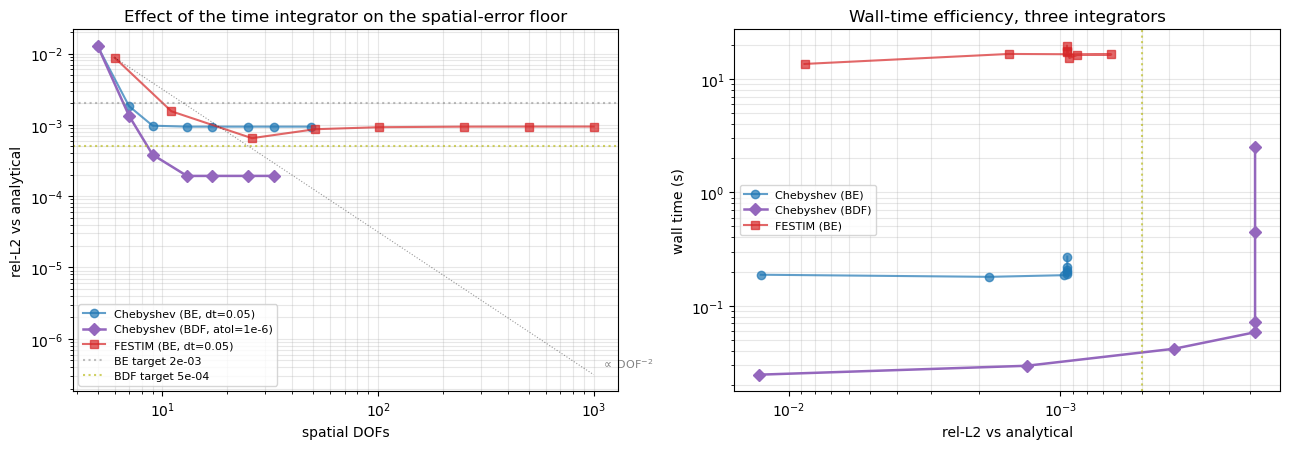

matched accuracy: rel-L2 < 5e-04

  Chebyshev (BDF): DOFs =    9  wall =  0.042 s   actual err = 3.81e-04
  Chebyshev (BE) : floors at 9.44e-04  (cannot reach 5e-04)
  FESTIM (BE)    : floors at 6.50e-04  (cannot reach 5e-04)


In [16]:
dofs_cheb_bdf = np.array(Ns_cheb_bdf) + 1
errs_cheb_bdf_arr = np.array(errs_cheb_bdf)

target_err_bdf = 5e-4
d_cb, w_cb, e_cb = _matched_accuracy(
    dofs_cheb_bdf, errs_cheb_bdf, times_cheb_bdf, target_err_bdf)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# panel 1: error vs DOFs (log-log) — three curves
ax[0].loglog(dofs_cheb, errs_cheb_arr, "o-", color="C0", lw=1.5, alpha=0.7,
             label="Chebyshev (BE, dt=0.05)")
ax[0].loglog(dofs_cheb_bdf, errs_cheb_bdf_arr, "D-", color="C4", lw=1.8,
             label="Chebyshev (BDF, atol=1e-6)")
ax[0].loglog(dofs_fes_arr, errs_fes_arr, "s-", color="C3", lw=1.5, alpha=0.7,
             label="FESTIM (BE, dt=0.05)")
ax[0].axhline(target_err, color="C7", ls=":", alpha=0.5,
              label=f"BE target {target_err:.0e}")
ax[0].axhline(target_err_bdf, color="C8", ls=":", alpha=0.7,
              label=f"BDF target {target_err_bdf:.0e}")

# slope-2 guide for FEM
d_lo, d_hi = dofs_fes_arr.min(), dofs_fes_arr.max()
e_lo = errs_fes_arr[0]
ax[0].loglog([d_lo, d_hi], [e_lo, e_lo * (d_hi / d_lo) ** -2],
             "k:", lw=0.8, alpha=0.4)
ax[0].annotate(r"$\propto$ DOF$^{-2}$",
               xy=(d_hi, e_lo * (d_hi / d_lo) ** -2),
               xytext=(5, 5), textcoords="offset points",
               fontsize=8, alpha=0.5)

ax[0].set_xlabel("spatial DOFs")
ax[0].set_ylabel("rel-L2 vs analytical")
ax[0].set_title("Effect of the time integrator on the spatial-error floor")
ax[0].grid(alpha=0.3, which="both"); ax[0].legend(fontsize=8, loc="lower left")

# panel 2: wall time vs error (efficiency frontier) — three curves
ax[1].loglog(errs_cheb_arr, times_cheb, "o-", color="C0", lw=1.5, alpha=0.7,
             label="Chebyshev (BE)")
ax[1].loglog(errs_cheb_bdf_arr, times_cheb_bdf, "D-", color="C4", lw=1.8,
             label="Chebyshev (BDF)")
ax[1].loglog(errs_fes_arr, times_fes, "s-", color="C3", lw=1.5, alpha=0.7,
             label="FESTIM (BE)")
ax[1].axvline(target_err_bdf, color="C8", ls=":", alpha=0.7)
ax[1].set_xlabel("rel-L2 vs analytical")
ax[1].set_ylabel("wall time (s)")
ax[1].set_title("Wall-time efficiency, three integrators")
ax[1].grid(alpha=0.3, which="both"); ax[1].legend(fontsize=8)
ax[1].invert_xaxis()

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "permeation_bdf_comparison.pdf"),
            bbox_inches="tight")
plt.show()

# matched-accuracy summary at the lower BDF target
print(f"matched accuracy: rel-L2 < {target_err_bdf:.0e}\n")
if d_cb is not None:
    print(f"  Chebyshev (BDF): DOFs = {d_cb:>4d}  wall = {w_cb:6.3f} s   "
          f"actual err = {e_cb:.2e}")
else:
    print(f"  Chebyshev (BDF): did not reach {target_err_bdf:.0e} in tested range")
print(f"  Chebyshev (BE) : floors at {min(errs_cheb):.2e}  (cannot reach {target_err_bdf:.0e})")
print(f"  FESTIM (BE)    : floors at {min(errs_fes):.2e}  (cannot reach {target_err_bdf:.0e})")